In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import os

FIG_DIR = "/content/drive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5"
TAB_DIR = "/content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5"

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

print("Figure dir:", FIG_DIR)
print("Table dir:", TAB_DIR)

Figure dir: /content/drive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5
Table dir: /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5


In [22]:
# ============================================================
# CELL 02 — Imports
# ============================================================

import os
import json
import math
import types
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

warnings.filterwarnings("ignore")

In [23]:
# ============================================================
# CELL 03 — Project config
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/thesis_rl_trading_final"

DATA_PROCESSED_DIR = f"{PROJECT_ROOT}/data_processed"
OUTPUTS_MODEL_DIR = f"{PROJECT_ROOT}/outputs/model_outputs"
OUTPUTS_EXPLAIN_DIR = f"{PROJECT_ROOT}/outputs/explainability"
CONFIGS_DIR = f"{PROJECT_ROOT}/configs"

TRANSFORMER_DIR = f"{OUTPUTS_MODEL_DIR}/transformer_ppo_final_5y"

for path in [
    DATA_PROCESSED_DIR,
    OUTPUTS_MODEL_DIR,
    OUTPUTS_EXPLAIN_DIR,
    CONFIGS_DIR,
    TRANSFORMER_DIR,
]:
    os.makedirs(path, exist_ok=True)

with open(f"{CONFIGS_DIR}/master_config.json", "r") as f:
    master_cfg = json.load(f)

ASSETS = master_cfg["assets"]
LOOKBACK = master_cfg["lookback"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("TRANSFORMER_DIR:", TRANSFORMER_DIR)
print("OUTPUTS_EXPLAIN_DIR:", OUTPUTS_EXPLAIN_DIR)
print("ASSETS:", ASSETS)
print("LOOKBACK:", LOOKBACK)
print("device:", device)

TRANSFORMER_DIR: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/transformer_ppo_final_5y
OUTPUTS_EXPLAIN_DIR: /content/drive/MyDrive/thesis_rl_trading_final/outputs/explainability
ASSETS: ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ']
LOOKBACK: 20
device: cpu


In [24]:
# ============================================================
# CELL 04 — Load 5Y env-ready data
# ============================================================

env_ready_5y = np.load(f"{DATA_PROCESSED_DIR}/env_ready_5y.npz", allow_pickle=True)

X_test = env_ready_5y["X_test"].astype(np.float32)
y_test = env_ready_5y["y_test"].astype(np.float32)
dates_test = env_ready_5y["dates_test"]

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("dates_test:", dates_test.shape)

X_test: (251, 20, 5, 13)
y_test: (251, 5)
dates_test: (251,)


In [25]:
# ============================================================
# CELL 05 — Find checkpoint file automatically
# ============================================================

candidate_names = [
    "best_model.pt",
    "best_model.pth",
    "model_best.pt",
    "model_best.pth",
    "best_checkpoint.pt",
    "best_checkpoint.pth",
    "checkpoint_best.pt",
    "checkpoint_best.pth",
    "final_model.pt",
    "final_model.pth",
]

existing = []
for name in candidate_names:
    fp = os.path.join(TRANSFORMER_DIR, name)
    if os.path.exists(fp):
        existing.append(fp)

if len(existing) == 0:
    all_ckpts = sorted(
        [str(p) for p in Path(TRANSFORMER_DIR).glob("*.pt")] +
        [str(p) for p in Path(TRANSFORMER_DIR).glob("*.pth")]
    )
else:
    all_ckpts = existing

print("Checkpoint candidates found:")
for fp in all_ckpts:
    print(" -", fp)

assert len(all_ckpts) > 0, "No checkpoint file found in transformer_ppo_final_5y folder."

CHECKPOINT_PATH = all_ckpts[0]
print("\nUsing checkpoint:", CHECKPOINT_PATH)

Checkpoint candidates found:
 - /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/transformer_ppo_final_5y/best_model.pt

Using checkpoint: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs/transformer_ppo_final_5y/best_model.pt


In [26]:
# ============================================================
# CELL 06 — Read state_dict and infer encoder dimensions
# ============================================================

import re
from pathlib import Path

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

assert isinstance(ckpt, (dict, torch.Tensor,)), "Unexpected checkpoint format."

if isinstance(ckpt, dict) and all(isinstance(k, str) for k in ckpt.keys()):
    state_dict = ckpt
else:
    raise RuntimeError("Checkpoint format not supported for state_dict loading.")

print("Checkpoint python type:", type(state_dict))
print("First 20 keys:", list(state_dict.keys())[:20])

# ---- infer dimensions from weights ----
assert "encoder.input_proj.weight" in state_dict, "Missing encoder.input_proj.weight"

d_model, input_dim = state_dict["encoder.input_proj.weight"].shape

# infer number of transformer layers
layer_ids = []
for k in state_dict.keys():
    m = re.match(r"encoder\.transformer\.layers\.(\d+)\.", k)
    if m:
        layer_ids.append(int(m.group(1)))
num_layers = max(layer_ids) + 1 if layer_ids else 1

# infer feedforward dim
ff_key = "encoder.transformer.layers.0.linear1.weight"
assert ff_key in state_dict, f"Missing {ff_key}"
dim_feedforward = state_dict[ff_key].shape[0]

# infer dropout / nhead from config files if available
candidate_cfgs = []
candidate_cfgs.extend(sorted([str(p) for p in Path(TRANSFORMER_DIR).glob("*.json")]))
candidate_cfgs.extend(sorted([str(p) for p in Path(CONFIGS_DIR).glob("*.json")]))

cfg_found = {}
for fp in candidate_cfgs:
    try:
        with open(fp, "r") as f:
            obj = json.load(f)
        if isinstance(obj, dict):
            cfg_found[fp] = obj
    except Exception:
        pass

print("\nJSON candidates:")
for fp in cfg_found.keys():
    print(" -", fp)

def recursive_find_key(d, target_keys):
    if isinstance(d, dict):
        for k, v in d.items():
            if k in target_keys:
                return v
            out = recursive_find_key(v, target_keys)
            if out is not None:
                return out
    return None

nhead = None
dropout = None
activation = "gelu"

for fp, obj in cfg_found.items():
    if nhead is None:
        nhead = recursive_find_key(obj, {"nhead", "num_heads"})
    if dropout is None:
        dropout = recursive_find_key(obj, {"dropout", "transformer_dropout"})
    act = recursive_find_key(obj, {"activation"})
    if act is not None:
        activation = act

# fallback guesses if config not found
if nhead is None:
    # choose a sensible divisor of d_model
    candidate_heads = [8, 4, 2, 1]
    valid = [h for h in candidate_heads if d_model % h == 0]
    nhead = valid[0] if len(valid) > 0 else 1

if dropout is None:
    dropout = 0.1

print("\nInferred encoder config:")
print("input_dim:", input_dim)
print("d_model:", d_model)
print("num_layers:", num_layers)
print("dim_feedforward:", dim_feedforward)
print("nhead:", nhead)
print("dropout:", dropout)
print("activation:", activation)

Checkpoint python type: <class 'collections.OrderedDict'>
First 20 keys: ['encoder.input_proj.weight', 'encoder.input_proj.bias', 'encoder.pos_encoder.pe', 'encoder.transformer.layers.0.self_attn.in_proj_weight', 'encoder.transformer.layers.0.self_attn.in_proj_bias', 'encoder.transformer.layers.0.self_attn.out_proj.weight', 'encoder.transformer.layers.0.self_attn.out_proj.bias', 'encoder.transformer.layers.0.linear1.weight', 'encoder.transformer.layers.0.linear1.bias', 'encoder.transformer.layers.0.linear2.weight', 'encoder.transformer.layers.0.linear2.bias', 'encoder.transformer.layers.0.norm1.weight', 'encoder.transformer.layers.0.norm1.bias', 'encoder.transformer.layers.0.norm2.weight', 'encoder.transformer.layers.0.norm2.bias', 'encoder.transformer.layers.1.self_attn.in_proj_weight', 'encoder.transformer.layers.1.self_attn.in_proj_bias', 'encoder.transformer.layers.1.self_attn.out_proj.weight', 'encoder.transformer.layers.1.self_attn.out_proj.bias', 'encoder.transformer.layers.1.li

In [27]:
# ============================================================
# CELL 07 — Define positional encoding + transformer encoder
# ============================================================

class PositionalEncodingFlexible(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 25):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(1, max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))

        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe, persistent=True)

    def forward(self, x):
        # x: [B, L, D]
        x = x + self.pe[:, :x.shape[1], :]
        return self.dropout(x)


class TransformerStateEncoder(nn.Module):
    def __init__(
        self,
        input_dim: int,
        d_model: int,
        nhead: int,
        num_layers: int,
        dim_feedforward: int,
        dropout: float = 0.1,
        activation: str = "gelu",
        max_len: int = 25,
    ):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncodingFlexible(
            d_model=d_model,
            dropout=dropout,
            max_len=max_len,
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation=activation,
            batch_first=True,
            norm_first=False,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )

    def forward(self, x):
        # x shape [B, L, N, F]
        b, l, n, f = x.shape
        x = x.reshape(b, l, n * f)
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        return x

In [28]:
# ============================================================
# CELL 08 — Build encoder and load encoder weights only
# ============================================================

pe_key = "encoder.pos_encoder.pe"
assert pe_key in state_dict, f"Missing {pe_key} in checkpoint"

# lấy max_len đúng theo checkpoint
if state_dict[pe_key].ndim == 3:
    checkpoint_max_len = int(state_dict[pe_key].shape[1])
elif state_dict[pe_key].ndim == 2:
    checkpoint_max_len = int(state_dict[pe_key].shape[0])
else:
    raise RuntimeError(f"Unsupported positional encoding shape: {state_dict[pe_key].shape}")

print("Using checkpoint_max_len:", checkpoint_max_len)
print("Checkpoint PE shape:", tuple(state_dict[pe_key].shape))
print("Input test sequence length:", X_test.shape[1])

encoder_model = TransformerStateEncoder(
    input_dim=input_dim,
    d_model=d_model,
    nhead=int(nhead),
    num_layers=int(num_layers),
    dim_feedforward=int(dim_feedforward),
    dropout=float(dropout),
    activation=str(activation),
    max_len=checkpoint_max_len,
).to(device)

encoder_state = {}
for k, v in state_dict.items():
    if k.startswith("encoder."):
        new_k = k[len("encoder."):]
        encoder_state[new_k] = v

missing, unexpected = encoder_model.load_state_dict(encoder_state, strict=False)

print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

encoder_model.eval()
print(encoder_model)

Using checkpoint_max_len: 25
Checkpoint PE shape: (1, 25, 128)
Input test sequence length: 20
Missing keys: []
Unexpected keys: ['post.0.weight', 'post.0.bias']
TransformerStateEncoder(
  (input_proj): Linear(in_features=65, out_features=128, bias=True)
  (pos_encoder): PositionalEncodingFlexible(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dr

In [29]:
# ============================================================
# CELL 09 — Patch TransformerEncoderLayer self-attention blocks
# ============================================================

def patch_transformer_encoder_layers(root_model: nn.Module):
    patched_count = 0

    for module in root_model.modules():
        if isinstance(module, nn.TransformerEncoderLayer):
            def wrapped_sa_block(self, x, attn_mask, key_padding_mask, is_causal=False):
                attn_output, attn_weights = self.self_attn(
                    x, x, x,
                    attn_mask=attn_mask,
                    key_padding_mask=key_padding_mask,
                    need_weights=True,
                    average_attn_weights=False,
                    is_causal=is_causal,
                )
                self._last_attn_weights = attn_weights.detach().cpu()
                return self.dropout1(attn_output)

            module._sa_block = types.MethodType(wrapped_sa_block, module)
            patched_count += 1

    return patched_count

patched_count = patch_transformer_encoder_layers(encoder_model)
print("Patched TransformerEncoderLayer blocks:", patched_count)

assert patched_count > 0, "No nn.TransformerEncoderLayer found."

Patched TransformerEncoderLayer blocks: 2


In [30]:
# ============================================================
# CELL 10 — Choose 2 representative test windows
# ============================================================

idx_1 = 0
market_move_score = np.mean(np.abs(y_test), axis=1)
idx_2 = int(np.argmax(market_move_score))

selected_indices = [idx_1, idx_2]
selected_dates = [str(dates_test[idx_1]), str(dates_test[idx_2])]

print("Selected indices:", selected_indices)
print("Selected dates:", selected_dates)
print("Market move score idx_2:", market_move_score[idx_2])

Selected indices: [0, 213]
Selected dates: ['2024-01-02', '2024-11-05']
Market move score idx_2: 0.036183663


In [31]:
# ============================================================
# CELL 10B — Disable optimized transformer fastpath
# ============================================================

# Disable PyTorch optimized MHA / transformer fastpath
try:
    torch.backends.mha.set_fastpath_enabled(False)
    print("Disabled torch MHA fastpath.")
except Exception as e:
    print("Could not disable MHA fastpath via torch.backends.mha:", repr(e))

# Important: run in train mode to avoid some eval-time fused fastpaths.
# We are NOT training, only forcing the Python path for inspection.
encoder_model.train()

print("encoder_model.training =", encoder_model.training)

Disabled torch MHA fastpath.
encoder_model.training = True


In [32]:
# ============================================================
# CELL 11 — Run encoder and collect attention matrices
# ============================================================

def extract_attention_stack_from_layers(model: nn.Module):
    stacks = []
    names = []

    for name, module in model.named_modules():
        if isinstance(module, nn.TransformerEncoderLayer):
            attn = getattr(module, "_last_attn_weights", None)
            if attn is not None:
                # expected [batch, heads, tgt_len, src_len]
                if attn.ndim == 4:
                    attn_np = attn[0].mean(dim=0).detach().cpu().numpy()
                elif attn.ndim == 3:
                    attn_np = attn[0].detach().cpu().numpy()
                else:
                    continue

                stacks.append(attn_np)
                names.append(name)

    return names, stacks


attention_results = {}

for idx, dt in zip(selected_indices, selected_dates):
    # reset old captured weights
    for module in encoder_model.modules():
        if isinstance(module, nn.TransformerEncoderLayer) and hasattr(module, "_last_attn_weights"):
            module._last_attn_weights = None

    x_np = X_test[idx:idx+1]
    x_tensor = torch.tensor(x_np, dtype=torch.float32, device=device)

    # do NOT use torch.no_grad() here; keep the standard Python execution path
    _ = encoder_model(x_tensor)

    layer_names, attn_stack = extract_attention_stack_from_layers(encoder_model)

    print(f"Sample idx={idx}, date={dt}, captured layers={len(attn_stack)}")

    for lname, amat in zip(layer_names, attn_stack):
        print("  ", lname, amat.shape)

    assert len(attn_stack) > 0, f"No attention matrices captured for sample index {idx}."

    attention_results[idx] = {
        "date": dt,
        "layer_names": layer_names,
        "attn_stack": attn_stack,
    }

Sample idx=0, date=2024-01-02, captured layers=2
   transformer.layers.0 (20, 20)
   transformer.layers.1 (20, 20)
Sample idx=213, date=2024-11-05, captured layers=2
   transformer.layers.0 (20, 20)
   transformer.layers.1 (20, 20)


In [33]:
# ============================================================
# CELL 12 — Build aggregate attention maps
# ============================================================

def build_aggregate_attention(attn_stack):
    min_tgt = min(a.shape[0] for a in attn_stack)
    min_src = min(a.shape[1] for a in attn_stack)

    cropped = [a[:min_tgt, :min_src] for a in attn_stack]
    agg = np.mean(np.stack(cropped, axis=0), axis=0)
    return agg

aggregate_maps = {}

for idx in selected_indices:
    agg = build_aggregate_attention(attention_results[idx]["attn_stack"])
    aggregate_maps[idx] = agg
    print(f"idx={idx}, aggregate attention shape={agg.shape}")

idx=0, aggregate attention shape=(20, 20)
idx=213, aggregate attention shape=(20, 20)


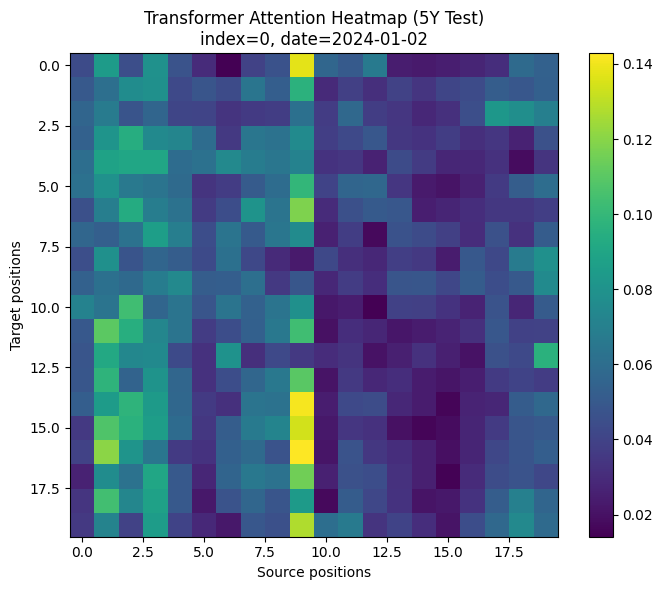

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/explainability/attention_heatmap_5y_idx_0.png


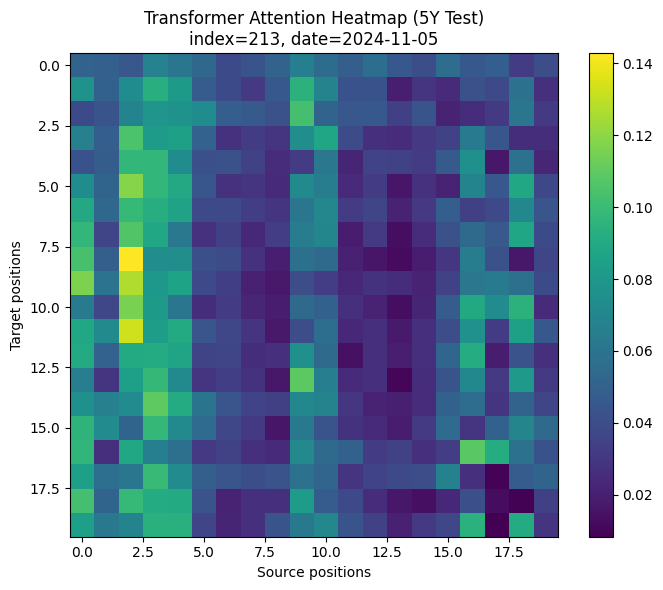

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/explainability/attention_heatmap_5y_idx_213.png


In [34]:
# ============================================================
# CELL 13 — Plot aggregate attention heatmaps
# ============================================================

for idx in selected_indices:
    agg = aggregate_maps[idx]
    dt = attention_results[idx]["date"]

    plt.figure(figsize=(7, 6))
    plt.imshow(agg, aspect="auto")
    plt.colorbar()
    plt.title(f"Transformer Attention Heatmap (5Y Test)\nindex={idx}, date={dt}")
    plt.xlabel("Source positions")
    plt.ylabel("Target positions")
    plt.tight_layout()

    save_path = f"{OUTPUTS_EXPLAIN_DIR}/attention_heatmap_5y_idx_{idx}.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.savefig(f"{FIG_DIR}/attention_single_1.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{FIG_DIR}/attention_single_2.png", dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)

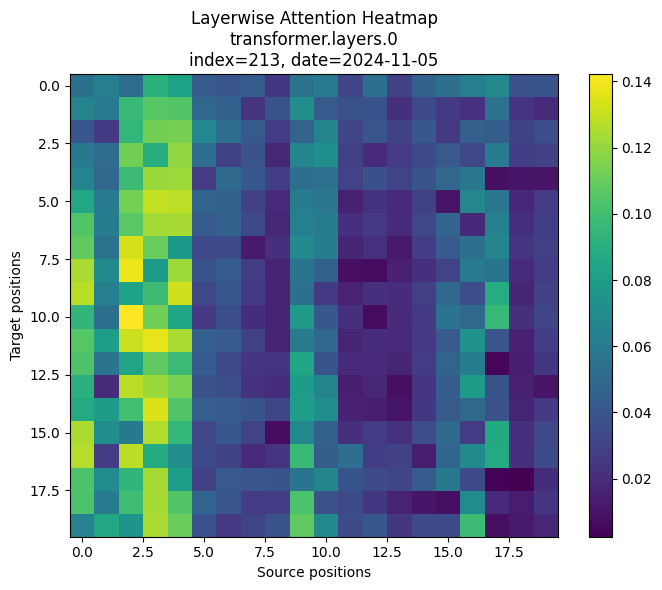

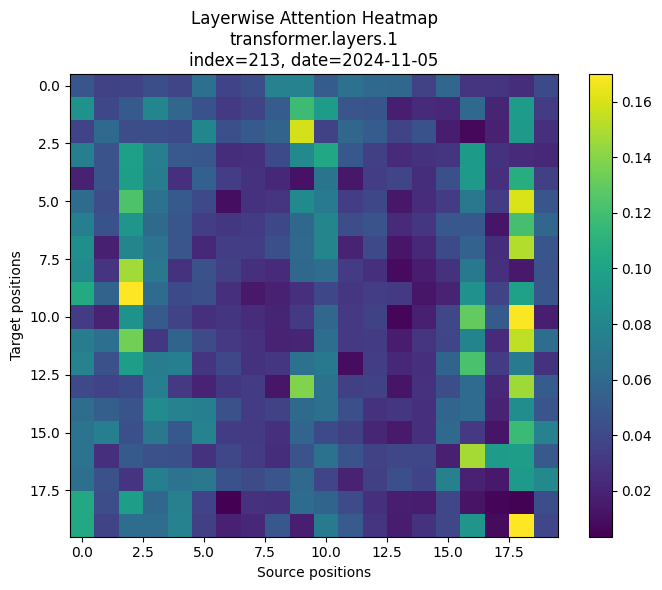

In [35]:
# ============================================================
# CELL 14 — Plot layerwise attention heatmaps
# ============================================================

focus_idx = idx_2

for layer_name, amat in zip(
    attention_results[focus_idx]["layer_names"],
    attention_results[focus_idx]["attn_stack"]
):
    plt.figure(figsize=(7, 6))
    plt.imshow(amat, aspect="auto")
    plt.colorbar()
    plt.title(
        f"Layerwise Attention Heatmap\n{layer_name}\n"
        f"index={focus_idx}, date={attention_results[focus_idx]['date']}"
    )
    plt.xlabel("Source positions")
    plt.ylabel("Target positions")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/attention_layerwise_example.png", dpi=300, bbox_inches="tight")
    plt.show()

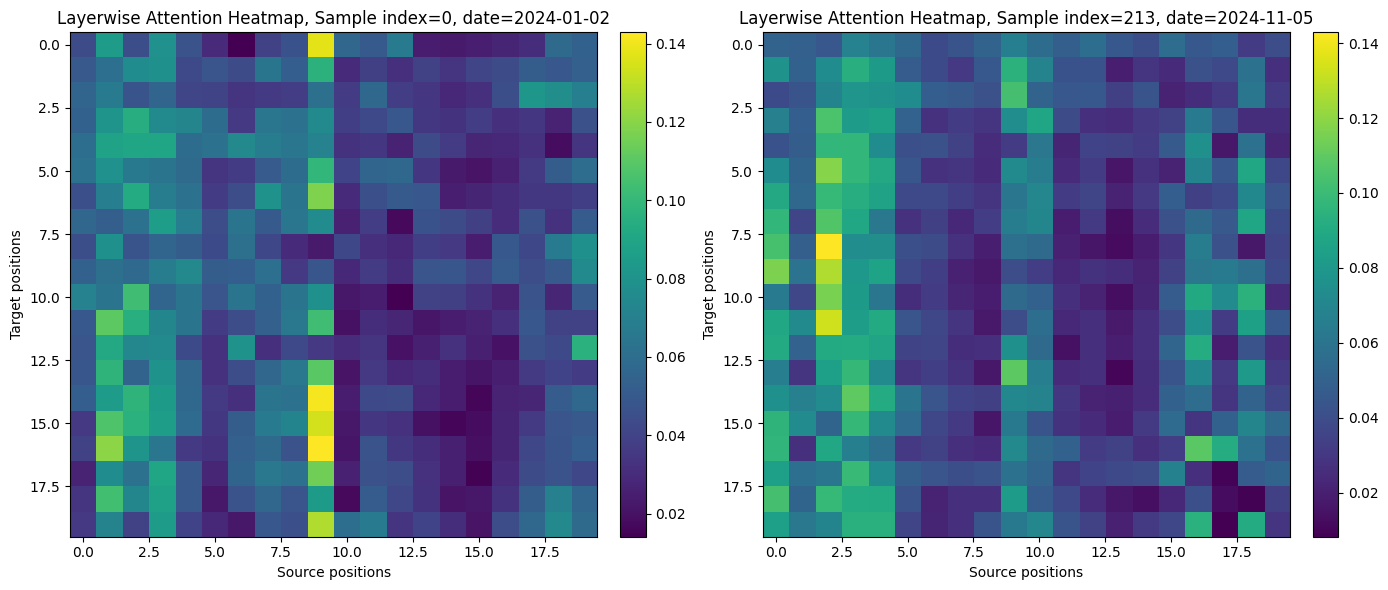

In [41]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(aggregate_maps[0], aspect="auto")
axes[0].set_title("Layerwise Attention Heatmap, Sample index=0, date=2024-01-02")
axes[0].set_xlabel("Source positions")
axes[0].set_ylabel("Target positions")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(aggregate_maps[213], aspect="auto")
axes[1].set_title("Layerwise Attention Heatmap, Sample index=213, date=2024-11-05")
axes[1].set_xlabel("Source positions")
axes[1].set_ylabel("Target positions")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/attention_single_pair_5y.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
# ============================================================
# CELL 15 — Save summary table
# ============================================================

summary_rows = []
for idx in selected_indices:
    agg = aggregate_maps[idx]
    summary_rows.append({
        "sample_index": idx,
        "date": attention_results[idx]["date"],
        "n_attention_layers_captured": len(attention_results[idx]["attn_stack"]),
        "attention_map_rows": int(agg.shape[0]),
        "attention_map_cols": int(agg.shape[1]),
        "attention_mean": float(np.mean(agg)),
        "attention_std": float(np.std(agg)),
        "attention_max": float(np.max(agg)),
        "attention_min": float(np.min(agg)),
    })

attention_summary_df = pd.DataFrame(summary_rows)
display(attention_summary_df)

attention_summary_df.to_csv(f"{OUTPUTS_EXPLAIN_DIR}/attention_summary_5y.csv", index=False)
attention_summary_df.to_csv(f"{TAB_DIR}/attention_single_summary_5y.csv", index=False)
print("Saved:", f"{OUTPUTS_EXPLAIN_DIR}/attention_summary_5y.csv")

,sample_index,date,n_attention_layers_captured,attention_map_rows,attention_map_cols,attention_mean,attention_std,attention_max,attention_min
0,0,2024-01-02,2,20,20,0.050282,0.023138,0.142876,0.014110
1,213,2024-11-05,2,20,20,0.050190,0.025938,0.142878,0.008262


Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/explainability/attention_summary_5y.csv


In [38]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=attention_summary_df)

https://docs.google.com/spreadsheets/d/1WVI3R-p0HNCP6sn_k7OGpVcn-pYAwbpbey6fliab4v4/edit#gid=0


In [39]:
# ============================================================
# CELL 16 — Final sanity checks
# ============================================================

required_files = [
    f"{OUTPUTS_EXPLAIN_DIR}/attention_summary_5y.csv",
    f"{OUTPUTS_EXPLAIN_DIR}/attention_heatmap_5y_idx_{idx_1}.png",
    f"{OUTPUTS_EXPLAIN_DIR}/attention_heatmap_5y_idx_{idx_2}.png",
]

for fp in required_files:
    assert os.path.exists(fp), f"Missing file: {fp}"

print("Attention heatmap notebook checks passed.")

Attention heatmap notebook checks passed.
